# Assignment3 - Supervised Learning - model training and evaluation

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


---
## Exercise 1 - Classification using logistic regression: build it from the ground up

**1.1 Load the data** 

Text(0.5, 1.0, 'Training Data Visualization')

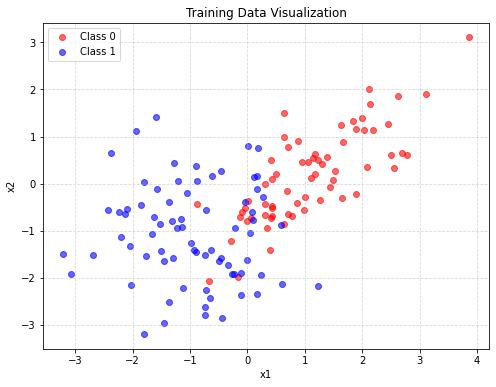

In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/A3_Q1_data.csv")
x = df[['x1', 'x2']].values
y = df['y'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], color='red', label='Class 0', alpha=0.6)
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Training Data Visualization')

Based on teh scatter plot, the two classes of data have some overlap in the feature space. The data appear to be not perfectly linear separable. However, logistic regression is still a good choice for these data because the overall distribution follows a clear linear trend.

**1.2**



In [6]:
print("Miss values in each column")
print(df.isnull().sum())

print("\nFeature statistics:")
print(df[['x1', 'x2']].describe())

Miss values in each column
x1    0
x2    0
y     0
dtype: int64

Feature statistics:
               x1          x2
count  200.000000  200.000000
mean     0.151376   -0.385426
std      1.411722    1.217490
min     -3.210005   -3.193456
25%     -0.912029   -1.341047
50%      0.112286   -0.479684
75%      1.174400    0.495114
max      3.867647    3.103541


I checked teh dataset for missing values using df.isnull().sum() and found that there are no missing entires across all columns. Regarding the scale of the features, the descriptive statistics show that both x1 and x2 have similar ranges and standard deviation. Since the scale are already comparable, extensive preprocessing like standarization is not strickly mandatory for convergence, though it remains a good practice. No other significant dat quality issue were identified. The data is ready for model fitting.

**1.3**

We assume that all N observations are independent and identically distributed. the total likelihood is the product of the individual likelihood for each training sample.       

For the single training sample, the likelihood is given by      
$$P(y_i | x_i; w) = [f(x_i, w)]^{y_i} \cdot [1 - f(x_i, w)]^{1-y_i}$$
For the entire dataset of N sample, the total likelihood function L(w) is       
$$L(w) = \prod_{i=1}^{N} P(y_i | x_i; w)$$
Substituting the individual likelihood,
$$L(w) = \prod_{i=1}^{N} \left( [f(x_i, w)]^{y_i} \cdot [1 - f(x_i, w)]^{1-y_i} \right)$$